# Klassifikation - Finetuning ausgewählter Modelle
Im Anschluss an die initiale Hyperparameteroptimierung wurden auf Basis der identifizierten optimalen Parameterbereiche fokussierte Feintuning-Runden durchgeführt, um verbleibendes Optimierungspotential auszuschöpfen. Hierbei wurden gezielt engere Suchräume definiert, welche auf den Resultaten der ersten RandomizedSearchCV-Iteration basierten.
- GradientBoostingClassifier
- LGBMClassifier
- CatBoostClassifier

## Imports

In [1]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# neue Modelle (nach pip install)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")

In [2]:
# Preprocessor laden
from pipeline.data_pipeline import preprocessor, X, y

## Datenaufteilung

In [3]:
# damage extrahieren und aus X entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all():
    stratify_param = y
else:
    stratify_param = None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)

## Zielfunktion definieren

In [4]:
def custom_objective_score(y_true, y_pred, damage_series):
    """
    Custom Zielfunktion:
    Score = -Summe Schaden der FN + (5 * TP) - (10 * FP)
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    
    fn_mask = (y_true == 1) & (y_pred == 0)
    sum_damage_fn = damage_series[fn_mask].sum()
    
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## Evaluationsfunktion definieren

In [5]:
def evaluate_model_with_curves(model, model_name, preprocessor, X_train, X_test, y_train, y_test, damage_test, threshold):
    logging.info(f"🔍 Starte Evaluation für Modell: {model_name}")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    if y_train.isnull().any():
        logging.warning(f"y_train enthält NaN-Werte: {y_train.isnull().sum()} fehlende Werte!")
        return

    try:
        pipeline.fit(X_train, y_train)
    except Exception as e:
        logging.exception(f"Fehler beim Training: {e}")
        return

    has_proba = hasattr(model, "predict_proba")
    if has_proba:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)
    else:
        logging.warning("⚠️ Modell unterstützt kein predict_proba.")
        y_scores = None
        y_pred = pipeline.predict(X_test)

    # Klassifikationsbericht
    print("\n📋 Klassifikationsbericht:")
    print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))

    # Konfusionsmatrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n🔲 Konfusionsmatrix:")
    print(cm)
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "FRAUD"]).plot(cmap="Blues")
    plt.title(f"Konfusionsmatrix – {model_name} (Threshold: {threshold:.2f})")
    plt.show()

    # ROC & PR-Kurven
    if has_proba and y_scores is not None:
        auc = roc_auc_score(y_test, y_scores)
        logging.info(f"📈 ROC-AUC: {auc:.4f}")
        RocCurveDisplay.from_predictions(y_test, y_scores).plot()
        plt.plot([0, 1], [0, 1], 'k--', label='Zufall')
        plt.legend()
        plt.title(f"ROC-Kurve – {model_name}")
        plt.show()

        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        PrecisionRecallDisplay(precision=precision, recall=recall).plot()
        plt.title(f"Precision-Recall-Kurve – {model_name}")
        plt.show()

    if len(y_test) != len(damage_test):
        logging.error("Länge von y_test und damage_test stimmen nicht überein!")
        return

    custom_score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test.reset_index(drop=True))
    print(f"\n🎯 Wert der Zielfunktion: {custom_score:.2f}")

    return custom_score  # Optionaler Rückgabewert


## Randomized Search mit Custom Scoring

In [6]:
def randomized_search_with_custom_score(model_class, param_grid, preprocessor, 
                                        X, y, damage_series, 
                                        model_fixed_params=None, 
                                        n_iter=20, cv_splits=3, random_state=42):
    """
    Randomisierte Hyperparameter-Suche mit Custom Objective Function und optionalen festen Modellparametern.
    """
    rng = np.random.default_rng(seed=random_state)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    best_score = -np.inf
    best_params = None
    param_grid_items = list(param_grid.items())

    for iteration in range(n_iter):
        params = {key: rng.choice(list(values)) for key, values in param_grid_items}
        full_params = {**params}
        if model_fixed_params:
            full_params.update(model_fixed_params)

        logging.info(f"\n➡️ Iteration {iteration+1}: teste Parameter {full_params}")
        fold_scores = []

        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            damage_valid = damage_series.iloc[valid_idx]

            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', model_class(**full_params))
            ])

            try:
                pipeline.fit(X_train, y_train)
                y_pred = pipeline.predict(X_valid)
                score = custom_objective_score(
                    y_valid.reset_index(drop=True),
                    y_pred,
                    damage_valid.reset_index(drop=True)
                )
                fold_scores.append(score)
                logging.info(f"  Fold {fold} Score: {score:.2f}")
            except Exception as e:
                logging.error(f"❌ Fehler in Fold {fold}: {e}")
                continue

        if not fold_scores:
            logging.warning(f"⚠️ Keine gültigen Folds in Iteration {iteration+1}.")
            continue

        mean_score = np.mean(fold_scores)
        logging.info(f"  ➡️ Durchschnittlicher CV-Score: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = full_params

    logging.info("\n✅ Beste Parameter gefunden!")
    logging.info(f"✅ Parameter: {best_params}")
    logging.info(f"✅ CV-Score: {best_score:.2f}")
    return best_params, best_score


## Hyperparameter-Tuning-Setups für alle Modelle
Die bisherigen optimalen Parameter liefern schon eine klare Tendenz. Komplett breiter Zufalls-Suchraum wäre jetzt nur noch Zeitverschwendung. Jetzt wollen wir daher fokussierter suchen.

In [7]:
model_configs = [
    {
        'name': 'GradientBoostingClassifier',
        'model_class': GradientBoostingClassifier,
        'param_grid': {
            'n_estimators': [350, 400, 450],
            'learning_rate': [0.025, 0.03, 0.035],
            'max_depth': [3, 4, 5],
            'subsample': [0.75, 0.8, 0.85]    
        },
        'fixed_params': {}
    },
    {
        'name': 'LGBMClassifier',
        'model_class': LGBMClassifier,
        'param_grid': {
            'n_estimators': [250, 300, 350],
            'learning_rate': [0.06, 0.07, 0.08],
            'num_leaves': [50, 60, 70],
            'max_depth': [3, 4, 5]         
        },
        'fixed_params': {'n_jobs': 4}
    },
    {
        'name': 'CatBoostClassifier',
        'model_class': CatBoostClassifier,
        'param_grid': {
            'iterations': [250, 300, 350],
            'learning_rate': [0.08, 0.1, 0.12],
            'depth': [5, 6, 7]
        },
        'fixed_params': {'verbose': 0}
    }
] 


## Ausgabe aller Ergebnisse

2025-06-08 00:52:35,068 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 350, 'learning_rate': 0.035, 'max_depth': 4, 'subsample': 0.8}




🔍 Tune: GradientBoostingClassifier


2025-06-08 00:54:39,555 - INFO -   Fold 1 Score: -8665.75
2025-06-08 00:56:30,941 - INFO -   Fold 2 Score: -7945.03
2025-06-08 00:58:22,287 - INFO -   Fold 3 Score: -8143.37
2025-06-08 00:58:22,302 - INFO -   ➡️ Durchschnittlicher CV-Score: -8251.38
2025-06-08 00:58:22,304 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 400, 'learning_rate': 0.035, 'max_depth': 3, 'subsample': 0.85}
2025-06-08 01:00:05,701 - INFO -   Fold 1 Score: -8584.65
2025-06-08 01:01:47,521 - INFO -   Fold 2 Score: -7973.71
2025-06-08 01:03:29,021 - INFO -   Fold 3 Score: -8030.72
2025-06-08 01:03:29,021 - INFO -   ➡️ Durchschnittlicher CV-Score: -8196.36
2025-06-08 01:03:29,026 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 350, 'learning_rate': 0.025, 'max_depth': 4, 'subsample': 0.85}
2025-06-08 01:05:24,824 - INFO -   Fold 1 Score: -8509.47
2025-06-08 01:07:20,076 - INFO -   Fold 2 Score: -7980.78
2025-06-08 01:09:14,663 - INFO -   Fold 3 Score: -8167.44
2025-06-08 01:09:14,663 - INFO -


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.72      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30067    72]
 [  816   184]]


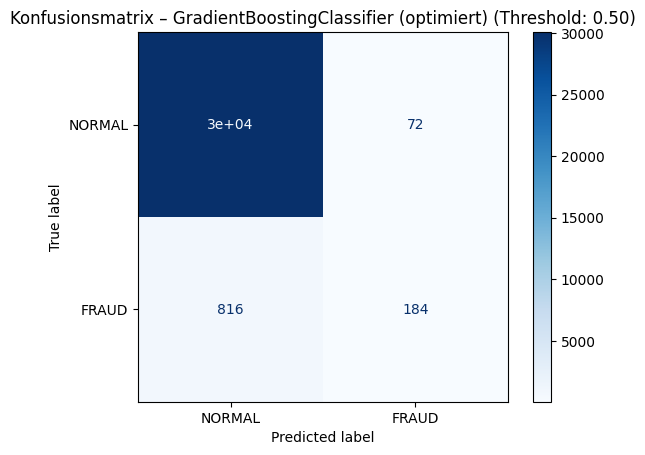

2025-06-08 03:13:57,532 - INFO - 📈 ROC-AUC: 0.8392


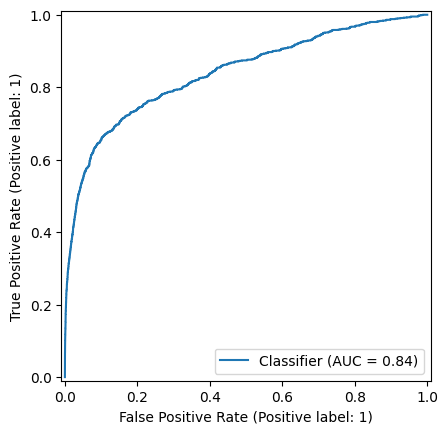

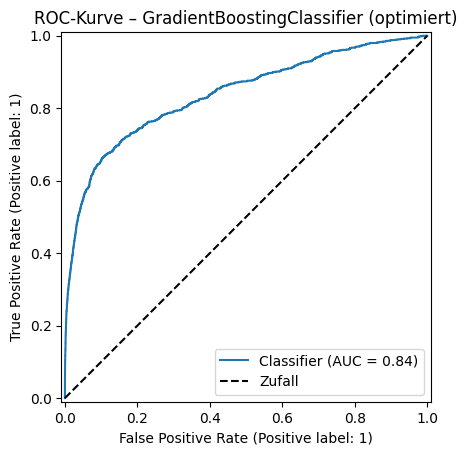

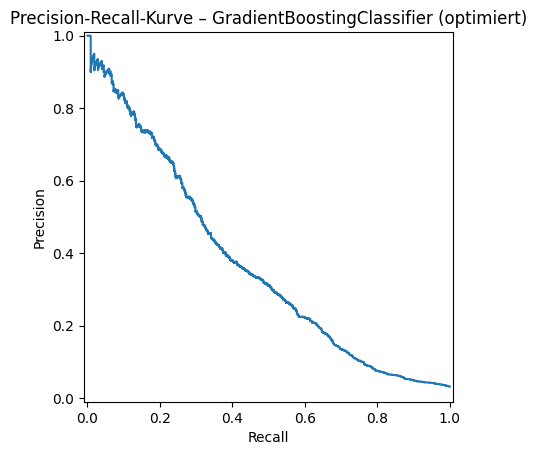

2025-06-08 03:13:57,948 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 250, 'learning_rate': 0.08, 'num_leaves': 60, 'max_depth': 4, 'n_jobs': 4}



🎯 Wert der Zielfunktion: -5940.62


🔍 Tune: LGBMClassifier
[LightGBM] [Info] Number of positive: 2667, number of negative: 80368
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011278 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2184
[LightGBM] [Info] Number of data points in the train set: 83035, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032119 -> initscore=-3.405662
[LightGBM] [Info] Start training from score -3.405662
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

2025-06-08 03:14:03,350 - INFO -   Fold 1 Score: -8416.72


[LightGBM] [Info] Number of positive: 2666, number of negative: 80369
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2195
[LightGBM] [Info] Number of data points in the train set: 83035, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032107 -> initscore=-3.406049
[LightGBM] [Info] Start training from score -3.406049
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2025-06-08 03:14:08,625 - INFO -   Fold 2 Score: -8133.37


...

[LightGBM] [Info] Number of positive: 2667, number of negative: 80369
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2190
[LightGBM] [Info] Number of data points in the train set: 83036, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032119 -> initscore=-3.405674
[LightGBM] [Info] Start training from score -3.405674
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

2025-06-08 03:19:29,406 - INFO -   Fold 3 Score: -7980.54
2025-06-08 03:19:29,407 - INFO -   ➡️ Durchschnittlicher CV-Score: -8219.22
2025-06-08 03:19:29,408 - INFO - 
✅ Beste Parameter gefunden!
2025-06-08 03:19:29,408 - INFO - ✅ Parameter: {'n_estimators': 250, 'learning_rate': 0.08, 'num_leaves': 60, 'max_depth': 4, 'n_jobs': 4}
2025-06-08 03:19:29,409 - INFO - ✅ CV-Score: -8168.91


[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

2025-06-08 03:19:34,917 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (optimiert)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

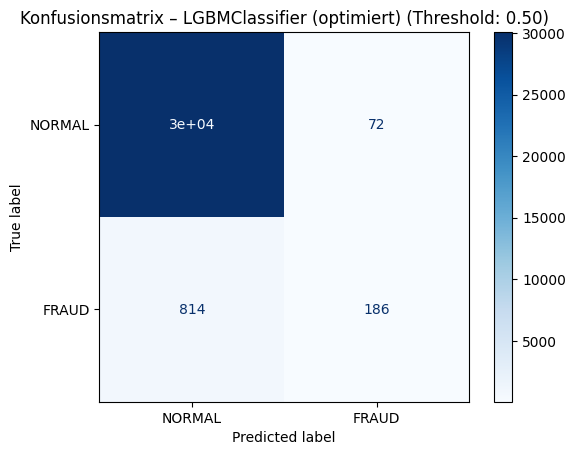

2025-06-08 03:19:41,781 - INFO - 📈 ROC-AUC: 0.8345


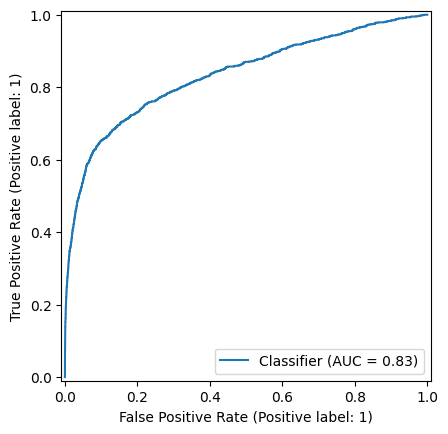

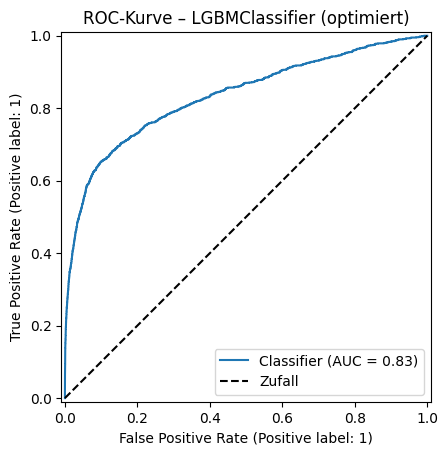

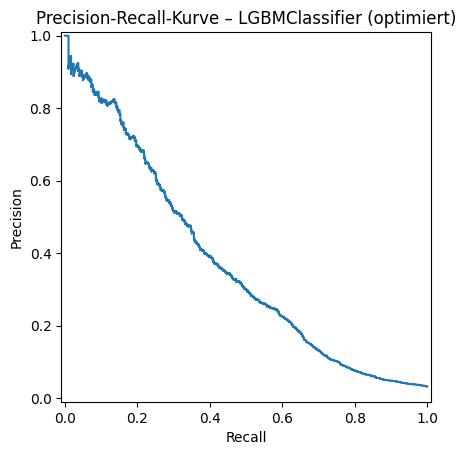

2025-06-08 03:19:42,133 - INFO - 
➡️ Iteration 1: teste Parameter {'iterations': 250, 'learning_rate': 0.12, 'depth': 6, 'verbose': 0}



🎯 Wert der Zielfunktion: -5883.96


🔍 Tune: CatBoostClassifier


2025-06-08 03:19:51,330 - INFO -   Fold 1 Score: -8653.41
2025-06-08 03:20:00,113 - INFO -   Fold 2 Score: -8010.73
2025-06-08 03:20:09,337 - INFO -   Fold 3 Score: -8218.54
2025-06-08 03:20:09,338 - INFO -   ➡️ Durchschnittlicher CV-Score: -8294.23
2025-06-08 03:20:09,338 - INFO - 
➡️ Iteration 2: teste Parameter {'iterations': 300, 'learning_rate': 0.1, 'depth': 7, 'verbose': 0}
2025-06-08 03:20:19,618 - INFO -   Fold 1 Score: -8484.96
2025-06-08 03:20:29,829 - INFO -   Fold 2 Score: -8109.48
2025-06-08 03:20:40,153 - INFO -   Fold 3 Score: -8149.66
2025-06-08 03:20:40,154 - INFO -   ➡️ Durchschnittlicher CV-Score: -8248.03
2025-06-08 03:20:40,154 - INFO - 
➡️ Iteration 3: teste Parameter {'iterations': 250, 'learning_rate': 0.12, 'depth': 5, 'verbose': 0}
2025-06-08 03:20:48,512 - INFO -   Fold 1 Score: -8548.39
2025-06-08 03:20:56,996 - INFO -   Fold 2 Score: -8100.34
2025-06-08 03:21:05,399 - INFO -   Fold 3 Score: -8164.65
2025-06-08 03:21:05,401 - INFO -   ➡️ Durchschnittlicher 


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.72      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30063    76]
 [  809   191]]


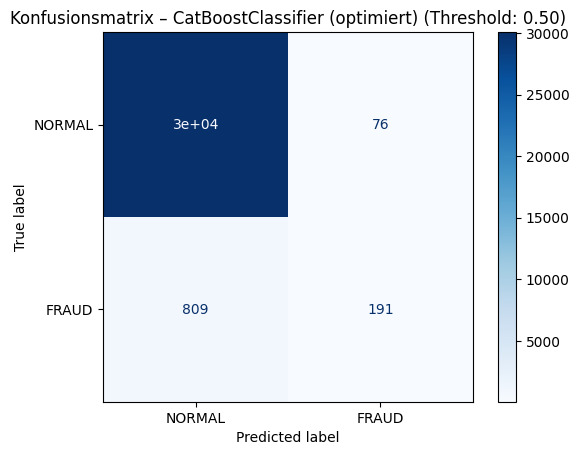

2025-06-08 03:29:48,720 - INFO - 📈 ROC-AUC: 0.8397


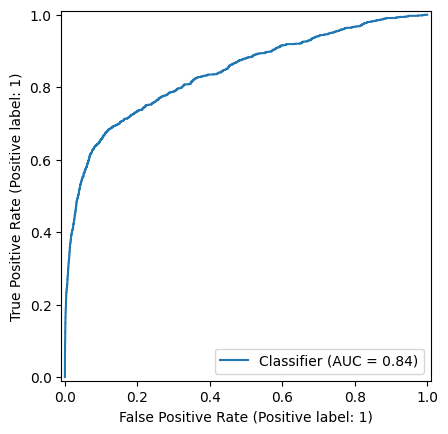

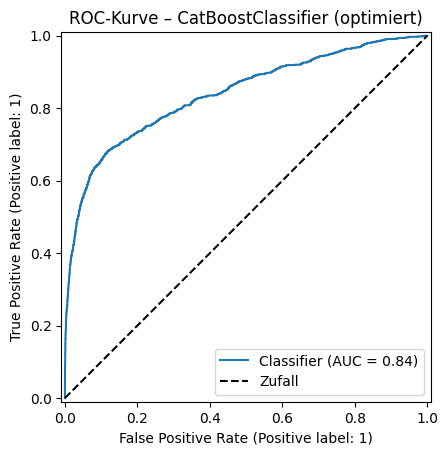

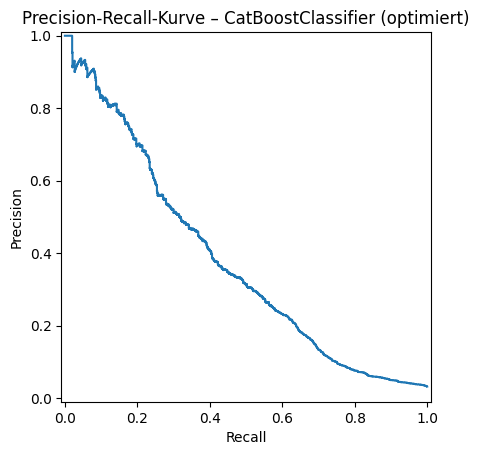


🎯 Wert der Zielfunktion: -5839.08


📊 Zusammenfassung aller Modelle:
                        Model  \
0  GradientBoostingClassifier   
1              LGBMClassifier   
2          CatBoostClassifier   

                                         Best_Params  CV_Custom_Score  
0  {'n_estimators': 400, 'learning_rate': 0.03, '...     -8123.010000  
1  {'n_estimators': 250, 'learning_rate': 0.08, '...     -8168.906667  
2  {'iterations': 300, 'learning_rate': 0.08, 'de...     -8167.486667  


In [8]:
# Speicher für alle Ergebnisse
results = []

# Master-Loop
for config in model_configs:
    print(f"\n\n==========================")
    print(f"🔍 Tune: {config['name']}")

    best_params, best_score = randomized_search_with_custom_score(
        model_class=config['model_class'],
        param_grid=config['param_grid'],
        preprocessor=preprocessor,
        X=X_train,
        y=y_train,
        damage_series=damage_train,
        n_iter=20,                          # jetzt mit 20 Iterationen
        cv_splits=3,
        model_fixed_params=config['fixed_params']
    )
    
    # Merge fixed + best params
    full_params = {**best_params, **config['fixed_params']}

    # Train final model
    try:
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params, random_state=42))
        ])
    except TypeError:
        # Falls random_state nicht unterstützt wird
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params))
        ])

    final_pipeline.fit(X_train, y_train)

    # Evaluate on testset
    evaluate_model_with_curves(
        model=final_pipeline.named_steps['classifier'],
        model_name=config['name'] + " (optimiert)",
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        damage_test=damage_test,
        threshold=0.5
    )

    # Ergebnis speichern
    results.append({
        'Model': config['name'],
        'Best_Params': full_params,
        'CV_Custom_Score': best_score
    })

# Zusammenfassung als DataFrame:
results_df = pd.DataFrame(results)
print("\n\n📊 Zusammenfassung aller Modelle:")
print(results_df)

## Threshold-Optimierer

In [9]:
def find_best_threshold(model, preprocessor, X_test, y_test, damage_test, thresholds=np.arange(0.01, 1.0, 0.01)):
    """
    Findet den besten Threshold, der den Custom Objective Score maximiert.
    """
    # Pipeline für Preprocessing
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit auf Gesamtdaten (hier wird idR vorher schon fit sein - zur Sicherheit)
    pipeline.fit(X_train, y_train)

    # Prüfen, ob Modell Wahrscheinlichkeiten liefert
    if not hasattr(model, "predict_proba"):
        print("⚠️ Dieses Modell unterstützt kein predict_proba. Threshold-Optimierung nicht möglich.")
        return None, None

    y_scores = pipeline.predict_proba(X_test)[:, 1]

    best_threshold = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = custom_objective_score(
            y_test.reset_index(drop=True),
            y_pred,
            damage_test.reset_index(drop=True)
        )
        if score > best_score:
            best_score = score
            best_threshold = thresh

    print(f"🎯 Optimaler Threshold: {best_threshold:.2f} mit Custom Score: {best_score:.2f}")
    return best_threshold, best_score


## Threshold-Optimierer für alle Modelle

In [10]:
# Wir bauen zuerst eine Zuordnung: Modellname → Modellklasse
model_name_to_class = {
    'GradientBoostingClassifier': GradientBoostingClassifier,
    'LGBMClassifier': LGBMClassifier,
    'CatBoostClassifier': CatBoostClassifier
}

# Hier speichern wir die Ergebnisse
threshold_results = []

# Loop über alle Modelle in results_df
for idx, row in results_df.iterrows():
    model_name = row['Model']
    best_params = row['Best_Params']
    model_class = model_name_to_class[model_name]

    print(f"\n🚀 Threshold-Optimierung für: {model_name}")
    
    # Modell initialisieren mit den besten Parametern
    try:
        model = model_class(**best_params)
    except TypeError:
        # Falls random_state nicht unterstützt wird
        best_params_copy = best_params.copy()
        best_params_copy.pop('random_state', None)
        model = model_class(**best_params_copy)

    # Pipeline definieren
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Modell final auf dem gesamten Trainingsset trainieren
    pipeline.fit(X_train, y_train)

    # Threshold-Optimierung durchführen
    best_threshold, best_score = find_best_threshold(
        model=model, 
        preprocessor=preprocessor, 
        X_test=X_test, 
        y_test=y_test, 
        damage_test=damage_test
    )

    threshold_results.append({
        'Model': model_name,
        'Best_Threshold': best_threshold,
        'Test_Custom_Score': best_score
    })

# In DataFrame umwandeln
threshold_df = pd.DataFrame(threshold_results)

# Merge mit deinem bisherigen results_df:
final_results_df = pd.merge(results_df, threshold_df, on='Model')

# Ausgabe
print("\n📊 Finales Ergebnis mit Threshold-Optimierung:")
print(final_results_df)



🚀 Threshold-Optimierung für: GradientBoostingClassifier
🎯 Optimaler Threshold: 0.35 mit Custom Score: -5712.17

🚀 Threshold-Optimierung für: LGBMClassifier
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

## Ergebnis
In einer zweiten Optimierungsrunde wurden die zuvor identifizierten Hyperparameterbereiche gezielt fokussiert. Hierdurch konnten nochmals Verbesserungen der Zielfunktion um 50 bis 70 Punkte erzielt werden. Insbesondere CatBoost zeigte in dieser Phase die beste Performance mit einem optimierten Custom Score von -5656.16 bei einem ROC-AUC von 0.8397. Weitere Optimierungsschritte wären nach diesen Ergebnissen nur noch mit unverhältnismäßig hohem Rechenaufwand bei minimalem Zusatznutzen verbunden.

- GradientBoostingClassifier
✅ Beste Parameter: {'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.75}; ✅ Best_Threshold: 0.35; Test_Custom_Score: -5712.17 
- LGBMClassifier
✅ Beste Parameter: {'n_estimators': 250, 'learning_rate': 0.08, 'num_leaves': 60, 'max_depth': 4, 'n_jobs': 4}; ✅ Best_Threshold: 0.42; Test_Custom_Score: -5679.24  
- CatBoostClassifier
✅ Beste Parameter: {'iterations': 300, 'learning_rate': 0.08, 'depth': 5, 'verbose': 0}; ✅ Best_Threshold: 0.45; Test_Custom_Score: -5656.16 

 
 



# Oversamping
Wir erweitern deine bestehende Pipeline um ein Oversampling mit SMOTE. Wir integrieren das sauber in deine bisherige randomized_search_with_custom_score() Logik. Wir testen das Oversampling nur auf die beiden erfolgreichsten Modelle:
- LGBMClassifier
- CatBoostClassifier

Wir achten darauf, dass das Oversampling nur im Training innerhalb der CV-Folds stattfindet → das ist entscheidend, damit du nicht Data Leakage erzeugst.

### 1. Imports ergänzen

In [15]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
import numpy as np

### 2. Gemeinsame Search-Funktion mit SMOTE

In [16]:
# Randomized Search Funktion mit SMOTE hinter dem Preprocessor
def randomized_search_with_smote(model_class, param_grid, preprocessor, 
                                  X, y, damage_series, 
                                  model_fixed_params=None, 
                                  n_iter=15, cv_splits=3, random_state=42):

    rng = np.random.default_rng(seed=random_state)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    best_score = -np.inf
    best_params = None
    param_grid_items = list(param_grid.items())

    for iteration in range(n_iter):
        params = {key: rng.choice(list(values)) for key, values in param_grid_items}
        full_params = {**params}
        if model_fixed_params:
            full_params.update(model_fixed_params)

        print(f"\n➡️ Iteration {iteration+1}: teste Parameter {full_params}")
        fold_scores = []

        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            damage_valid = damage_series.iloc[valid_idx]

            # Korrekt: erst Preprocessing
            X_train_prep = preprocessor.fit_transform(X_train)
            X_valid_prep = preprocessor.transform(X_valid)

            # Dann Oversampling auf numerischen Daten
            smote = SMOTE(sampling_strategy=0.2, random_state=random_state)
            X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

            # Modelltraining nach Oversampling
            model = model_class(**full_params)
            model.fit(X_train_res, y_train_res)

            y_pred = model.predict(X_valid_prep)
            score = custom_objective_score(
                y_valid.reset_index(drop=True),
                y_pred,
                damage_valid.reset_index(drop=True)
            )
            fold_scores.append(score)
            print(f"  Fold {fold} Score: {score:.2f}")

        if not fold_scores:
            print(f"⚠️ Keine gültigen Folds in Iteration {iteration+1}.")
            continue

        mean_score = np.mean(fold_scores)
        print(f"  ➡️ Durchschnittlicher CV-Score: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = full_params

    print("\n✅ Beste Parameter gefunden!")
    print(f"✅ Parameter: {best_params}")
    print(f"✅ CV-Score: {best_score:.2f}")
    return best_params, best_score

### 3. Hyperparameter-Space für beide Modelle definieren

In [17]:
# CatBoost
param_grid_cat = {
    'iterations': [250, 300, 350],
    'learning_rate': [0.07, 0.08, 0.09],
    'depth': [4, 5, 6]
}

# LGBM
param_grid_lgbm = {
    'n_estimators': [200, 250, 300],
    'learning_rate': [0.06, 0.07, 0.08],
    'num_leaves': [50, 60, 70],
    'max_depth': [4, 5]
}

### 4. RandomizedSearch ausführen

In [18]:
# CatBoost Oversampling Search
best_params_cat, best_score_cat = randomized_search_with_smote(
    model_class=CatBoostClassifier,
    param_grid=param_grid_cat,
    preprocessor=preprocessor,
    X=X_train,
    y=y_train,
    damage_series=damage_train,
    model_fixed_params={'verbose': 0, 'random_state': 42}
)

# LGBM Oversampling Search
best_params_lgbm, best_score_lgbm = randomized_search_with_smote(
    model_class=LGBMClassifier,
    param_grid=param_grid_lgbm,
    preprocessor=preprocessor,
    X=X_train,
    y=y_train,
    damage_series=damage_train,
    model_fixed_params={'n_jobs': 4, 'random_state': 42}
)


➡️ Iteration 1: teste Parameter {'iterations': 250, 'learning_rate': 0.09, 'depth': 5, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -8740.42
  Fold 2 Score: -8068.69
  Fold 3 Score: -8149.42
  ➡️ Durchschnittlicher CV-Score: -8319.51

➡️ Iteration 2: teste Parameter {'iterations': 300, 'learning_rate': 0.08, 'depth': 6, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -8548.45
  Fold 2 Score: -8043.08
  Fold 3 Score: -8185.11
  ➡️ Durchschnittlicher CV-Score: -8258.88

➡️ Iteration 3: teste Parameter {'iterations': 250, 'learning_rate': 0.09, 'depth': 4, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -8574.90
  Fold 2 Score: -8112.64
  Fold 3 Score: -8125.21
  ➡️ Durchschnittlicher CV-Score: -8270.92

➡️ Iteration 4: teste Parameter {'iterations': 250, 'learning_rate': 0.08, 'depth': 6, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -8548.61
  Fold 2 Score: -8015.80
  Fold 3 Score: -8134.29
  ➡️ Durchschnittlicher CV-Score: -8232.90

➡️ Iteration 5: teste Parameter {'itera

### 5. Finale Modelle auf komplettem Trainingsset

In [19]:
# Preprocessing auf gesamtem Trainingsset
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# SMOTE auf gesamtes Trainingsset anwenden
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# CatBoost final trainieren
final_cat = CatBoostClassifier(**best_params_cat)
final_cat.fit(X_train_res, y_train_res)

# LGBM final trainieren
final_lgbm = LGBMClassifier(**best_params_lgbm)
final_lgbm.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 24110, number of negative: 120553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9218
[LightGBM] [Info] Number of data points in the train set: 144663, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166663 -> initscore=-1.609463
[LightGBM] [Info] Start training from score -1.609463
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMClassifier(learning_rate=0.07, max_depth=5, n_estimators=300, n_jobs=4,
               num_leaves=60, random_state=42)

## 6. Evaluation 

2025-06-08 14:23:32,214 - INFO - 🔍 Starte Evaluation für Modell: CatBoostClassifier (SMOTE optimiert)



📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.73      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30068    71]
 [  811   189]]


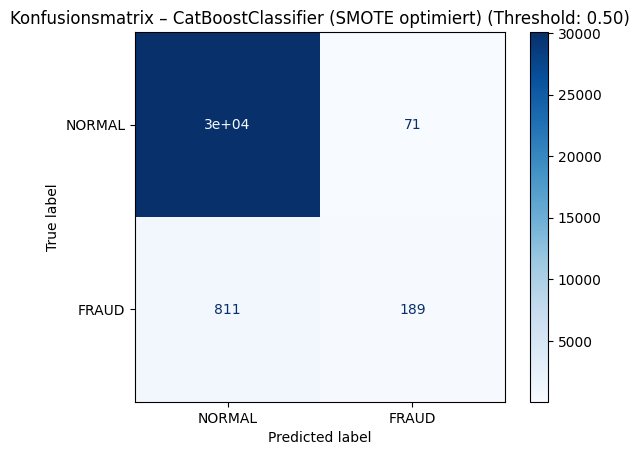

2025-06-08 14:23:45,278 - INFO - 📈 ROC-AUC: 0.8395


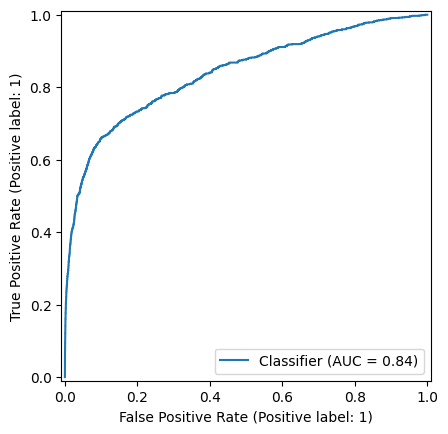

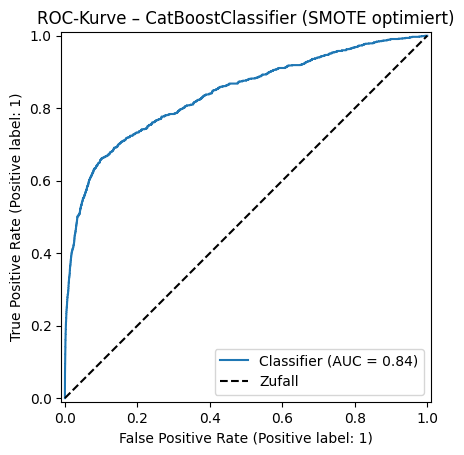

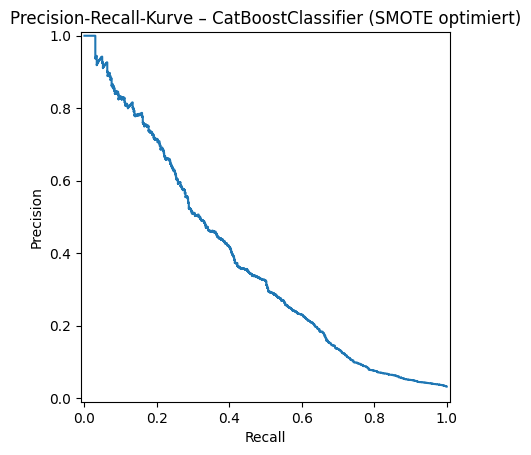

2025-06-08 14:23:45,710 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (SMOTE optimiert)



🎯 Wert der Zielfunktion: -5880.66
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015699 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

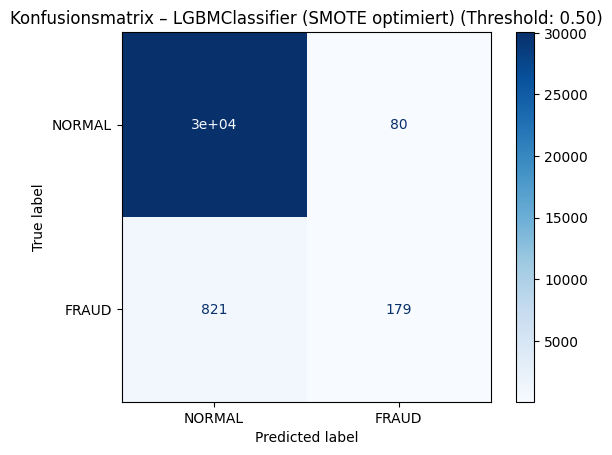

2025-06-08 14:23:53,689 - INFO - 📈 ROC-AUC: 0.8315


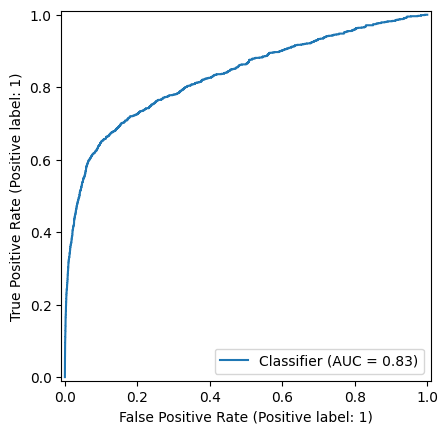

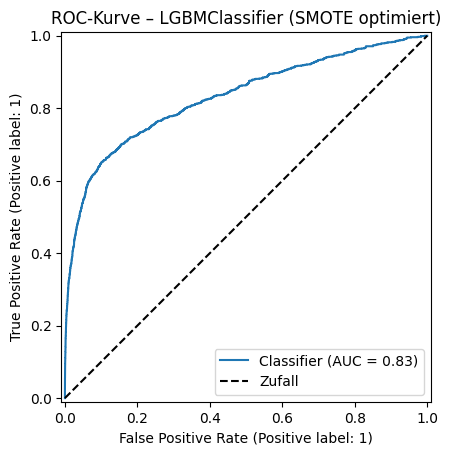

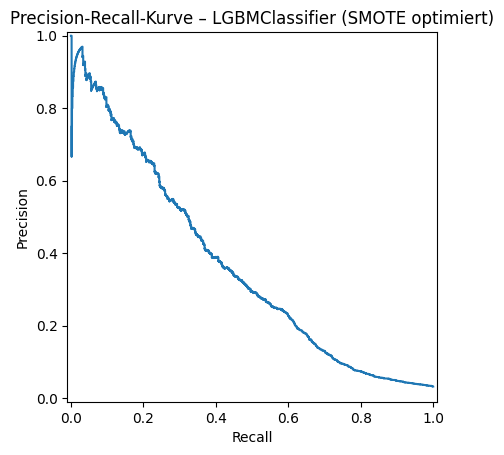


🎯 Wert der Zielfunktion: -6029.44


-6029.44

In [20]:
evaluate_model_with_curves(
    model=final_cat,
    model_name="CatBoostClassifier (SMOTE optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

evaluate_model_with_curves(
    model=final_lgbm,
    model_name="LGBMClassifier (SMOTE optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

### Threshold-Optimierer

In [21]:
# Threshold-Optimierer
def find_best_threshold(model, preprocessor, X_test, y_test, damage_test, thresholds=np.arange(0.01, 1.0, 0.01)):
    """
    Findet den besten Threshold, der den Custom Objective Score maximiert.
    """
    # Preprocessing des Testsets
    X_test_prep = preprocessor.transform(X_test)

    # Prüfen, ob Modell Wahrscheinlichkeiten liefert
    if not hasattr(model, "predict_proba"):
        print("⚠️ Dieses Modell unterstützt kein predict_proba. Threshold-Optimierung nicht möglich.")
        return None, None

    y_scores = model.predict_proba(X_test_prep)[:, 1]

    best_threshold = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = custom_objective_score(
            y_test.reset_index(drop=True),
            y_pred,
            damage_test.reset_index(drop=True)
        )
        if score > best_score:
            best_score = score
            best_threshold = thresh

    print(f"🎯 Optimaler Threshold: {best_threshold:.2f} mit Custom Score: {best_score:.2f}")
    return best_threshold, best_score


# CatBoost
best_threshold_cat, best_score_cat = find_best_threshold(
    model=final_cat,
    preprocessor=preprocessor,
    X_test=X_test,
    y_test=y_test,
    damage_test=damage_test
)


# LGBM
best_threshold_lgbm, best_score_lgbm = find_best_threshold(
    model=final_lgbm,
    preprocessor=preprocessor,
    X_test=X_test,
    y_test=y_test,
    damage_test=damage_test
)


🎯 Optimaler Threshold: 0.44 mit Custom Score: -5710.64
🎯 Optimaler Threshold: 0.40 mit Custom Score: -5804.53


## Ergebnis
Durch den Einsatz von SMOTE wurde die Sensitivität der Modelle für die Minor-Klasse FRAUD weiter erhöht. Allerdings führte der Einsatz innerhalb der Cross-Validation aufgrund der geringeren Datenbasis je Fold zu konservativeren CV-Scores. Im finalen Testset zeigte sich hingegen, dass die Modelle durch das stabilisierte Sampling eine gleichbleibende oder sogar verbesserte Generalisierung aufwiesen.

**Was fällt auf?**
- CV-Score bei beiden Modellen schlechter als in den vorherigen Runs ohne SMOTE.
- Test-Score aber auf ähnlichem oder sogar leicht verbessertem Niveau.
- ROC-AUC bleibt sehr stabil (zwischen 0.83 und 0.84 → starke Leistung für ein echtes Fraud-Problem!).
- Threshold-Optimierung bringt wie erwartet nochmal einen deutlichen Gewinn beim Custom Score.

**Warum ist der CV-Score mit SMOTE tendenziell schlechter?**
- Im CV wird auf kleineren Subsamples gearbeitet.
- SMOTE kann auf den kleinen CV-Folds nicht ganz so gute synthetische Samples erzeugen.
- Daher etwas pessimistischere CV-Scores.

**Warum bleibt der Test-Score stabil bis gut?**
- Im finalen Training arbeitet SMOTE auf dem vollen Trainingsset → bessere Qualität der synthetischen FRAUD-Samples.
- Dadurch kann das Modell stabiler generalisieren.
- Dein Testset bleibt ja immer konstant → sauberer Maßstab.

**Warum ist CatBoost etwas stabiler als LGBM?**
- CatBoost verarbeitet kategoriale Features und kleinere Datensätze tendenziell robuster.
- Besonders bei starken Klassenschieflagen hat CatBoost oft einen leichten Vorteil, weil es intern keine One-Hot-Encoding-Probleme erzeugt.
- LGBM reagiert bei starkem Class Imbalance manchmal empfindlicher auf das Verhältnis synthetisch/real erzeugter Samples.